# 07 - Auditoria: analisis SHAP global y local

**Objetivo:** Calcular y visualizar valores SHAP globales y locales para ambos modelos de
coste, para explicar que variables determinan las decisiones del modelo en conjunto y en casos
individuales.

**Entregable(s) que produce este notebook:**
- `results/tables/shap_values_global.csv`
- `results/figures/shap_summary_coste1.png`
- `results/figures/shap_summary_coste10.png`
- `results/figures/shap_local_*.png`

## Conectores

**Que recibe de los notebooks anteriores:**
- `results/models/modelo_coste1.joblib` (de `03_modelo_coste1.ipynb`)
- `results/models/modelo_coste10.joblib` (de `04_modelo_coste10.ipynb`)
- `data/processed/test.parquet` (de `02_preprocesado.ipynb`)

**Que entrega a los notebooks siguientes:**
- Valores y figuras SHAP (`results/tables/shap_values_global.csv`,
  `results/figures/shap_summary_coste1.png`, `results/figures/shap_summary_coste10.png`,
  `results/figures/shap_local_*.png`)

consumidos por `99_ENTREGA.ipynb` (seccion de auditoria).

## Decisiones que afectan a este notebook

- **D-0.3** (familia de modelo: arboles boosted vs red neuronal vs lineal): **CERRADA** en
  `docs/DECISIONES.md` a favor de **XGBoost** (arboles boosted). Esto fija el Explainer de SHAP a
  usar: **`TreeExplainer`** (exacto y rapido para modelos de arboles), sin necesidad de
  `KernelExplainer`/`LinearExplainer` ni de muestra de background. Segun `docs/teoria/shap.md`
  (seccion "Sobre la eleccion de Explainer segun familia de modelo"), el material del profesor
  (`XAI.pdf`, pp. 200-204) no menciona estos nombres de implementacion; la eleccion se apoya en
  D-0.3 y en la libreria `shap`. Nota tecnica: en XGBoost los valores SHAP son aditivos en el
  espacio *log-odds* (margin), no en probabilidad; tenerlo en cuenta al cruzar SHAP local con
  los contrafactuales del `06` (seccion 4).
- **Propuesta D-7.1** (numero de ejemplos para SHAP local): pendiente de fijar aqui. El numero
  de ejemplos locales debe coincidir con los casos usados en `06_contrafactuals.ipynb` (seccion 4
  de este notebook), para poder comparar explicacion SHAP local y contrafactual sobre las mismas
  instancias.
- Nota adicional (D-0.2, CERRADA): `modelo_coste1` y `modelo_coste10` comparten el **mismo**
  modelo XGBoost y se diferencian solo en el umbral de decision. Por tanto los valores SHAP del
  score son los mismos en ambos escenarios; lo que cambia entre escenarios no es la atribucion
  del score sino el umbral que convierte ese score en DECISION. Las secciones 2-4 mantienen los
  dos escenarios de forma explicita para dejar clara esa relacion y compararla en la seccion 5.

## 1. Carga de los modelos entrenados y del conjunto de test

Carga de `results/models/modelo_coste1.joblib`, `results/models/modelo_coste10.joblib` y
`data/processed/test.parquet`, para disponer de las entradas (X) sobre las que se calcularan
los valores SHAP.

In [1]:
# Carga del modelo del escenario simétrico y del conjunto de test
from pathlib import Path
import sys
import joblib
import pandas as pd

# Permite ejecutar el notebook tanto desde la raíz como desde notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

modelo_coste1 = joblib.load(
    ROOT / "results" / "models" / "modelo_coste1.joblib"
)

test = pd.read_parquet(
    ROOT / "data" / "processed" / "test.parquet"
)

TARGET = "SeriousDlqin2yrs"
COLUMNAS_NO_MODELO = [TARGET, "id_fila_original"]

X_test = test.drop(
    columns=[c for c in COLUMNAS_NO_MODELO if c in test.columns]
)
y_test = test[TARGET].astype("int64")

print("Escenario: coste 1 (C_FP = C_FN = 1)")
print(f"Modelo cargado: {type(modelo_coste1).__name__}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Observaciones de y_test: {len(y_test):,}")

Escenario: coste 1 (C_FP = C_FN = 1)
Modelo cargado: dict
Dimensiones de X_test: (21000, 12)
Observaciones de y_test: 21,000


In [2]:
# Carga del modelo del escenario asimétrico y del conjunto de test
from pathlib import Path
import sys
import joblib
import pandas as pd

# Permite ejecutar el notebook tanto desde la raíz como desde notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

modelo_coste10 = joblib.load(
    ROOT / "results" / "models" / "modelo_coste10.joblib"
)

test = pd.read_parquet(
    ROOT / "data" / "processed" / "test.parquet"
)

TARGET = "SeriousDlqin2yrs"
COLUMNAS_NO_MODELO = [TARGET, "id_fila_original"]

X_test = test.drop(
    columns=[c for c in COLUMNAS_NO_MODELO if c in test.columns]
)
y_test = test[TARGET].astype("int64")

print("Escenario: coste 10 (C_FP = 1, C_FN = 10)")
print(f"Modelo cargado: {type(modelo_coste10).__name__}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Observaciones de y_test: {len(y_test):,}")

Escenario: coste 10 (C_FP = 1, C_FN = 10)
Modelo cargado: dict
Dimensiones de X_test: (21000, 12)
Observaciones de y_test: 21,000


## 2. Calculo de valores SHAP globales

Instanciar el Explainer de SHAP adecuado segun la familia de modelo (D-0.3) y calcular los
valores SHAP sobre el conjunto de test para `modelo_coste1` y `modelo_coste10` por separado,
guardando el resultado en `results/tables/shap_values_global.csv`.

In [3]:
# 2. Calculo de valores SHAP globales
import numpy as np
import pandas as pd
import shap

def extraer_modelo_xgboost(bundle, nombre):
    """Extrae el estimador XGBoost almacenado dentro del bundle."""
    modelo = bundle.get("modelo") if isinstance(bundle, dict) else bundle
    estimador = getattr(modelo, "estimador_", modelo)

    if "xgboost" not in type(estimador).__module__.lower():
        raise TypeError(
            f"{nombre} no contiene un estimador XGBoost compatible "
            f"con TreeExplainer: {type(estimador).__name__}"
        )

    return modelo, estimador

def calcular_shap_global(bundle, nombre):
    """Calcula los valores SHAP y su resumen global para un escenario."""
    modelo, estimador = extraer_modelo_xgboost(bundle, nombre)

    features = (
        bundle.get("features") if isinstance(bundle, dict) else None
    ) or getattr(modelo, "nombres_features_", list(X_test.columns))

    faltantes = sorted(set(features) - set(X_test.columns))

    if faltantes:
        raise ValueError(
            f"Faltan columnas requeridas por {nombre}: {faltantes}"
        )

    X = X_test.loc[:, features]

    # D-0.3: la familia elegida es XGBoost.
    explainer = shap.TreeExplainer(estimador)
    valores_shap = explainer(X)

    matriz_shap = np.asarray(valores_shap.values)

    # Compatibilidad con explainers que devuelven una salida por clase.
    if matriz_shap.ndim == 3:
        matriz_shap = matriz_shap[:, :, 1]
    if matriz_shap.shape != X.shape:
        raise ValueError(
            f"Forma SHAP inesperada para {nombre}: "
            f"{matriz_shap.shape}; esperada: {X.shape}"
        )
    resumen = pd.DataFrame({
        "escenario": nombre,
        "feature": features,
        "mean_abs_shap": np.abs(matriz_shap).mean(axis=0),
        "mean_shap": matriz_shap.mean(axis=0),
    })
    resumen = resumen.sort_values(
        "mean_abs_shap",
        ascending=False,
        ignore_index=True,
    )
    resumen["ranking"] = np.arange(1, len(resumen) + 1)

    return explainer, valores_shap, resumen

# Calculo independiente para cada escenario.
explainer_coste1, shap_values_coste1, resumen_shap_coste1 = (
    calcular_shap_global(modelo_coste1, "coste1")
)
explainer_coste10, shap_values_coste10, resumen_shap_coste10 = (
    calcular_shap_global(modelo_coste10, "coste10")
)

# Tabla global conjunta.
shap_global = pd.concat(
    [resumen_shap_coste1, resumen_shap_coste10],
    ignore_index=True,
)

# Guardado del resultado.
ruta_shap_global = (
    ROOT / "results" / "tables" / "shap_values_global.csv"
)
ruta_shap_global.parent.mkdir(parents=True, exist_ok=True)
shap_global.to_csv(ruta_shap_global, index=False)

print(
    f"Valores SHAP calculados sobre {len(X_test):,} "
    "observaciones por escenario."
)
print(
    "Resumen global guardado en: "
    f"{ruta_shap_global.relative_to(ROOT)}"
)
display(shap_global)

Valores SHAP calculados sobre 21,000 observaciones por escenario.
Resumen global guardado en: results\tables\shap_values_global.csv


,escenario,feature,mean_abs_shap,mean_shap,ranking
0,coste1,RevolvingUtilizationOfUnsecuredLines,0.787252,-0.357671,1
1,coste1,NumberOfTime30-59DaysPastDueNotWorse,0.348599,-0.122427,2
2,coste1,NumberOfTimes90DaysLate,0.327756,-0.164462,3
3,coste1,age,0.227283,-0.065420,4
4,coste1,NumberOfTime60-89DaysPastDueNotWorse,0.173540,-0.060291,5
5,coste1,NumberOfOpenCreditLinesAndLoans,0.159189,-0.015808,6
6,coste1,DebtRatio,0.129320,-0.017772,7
7,coste1,MonthlyIncome,0.088239,-0.024007,8
8,coste1,NumberRealEstateLoansOrLines,0.068172,-0.015856,9
9,coste1,NumberOfDependents,0.043470,-0.005974,10


## 3. Visualizacion de importancia global de variables

Generar los graficos resumen (summary plot) de importancia global de variables para cada
escenario, guardandolos en `results/figures/shap_summary_coste1.png` y
`results/figures/shap_summary_coste10.png`.

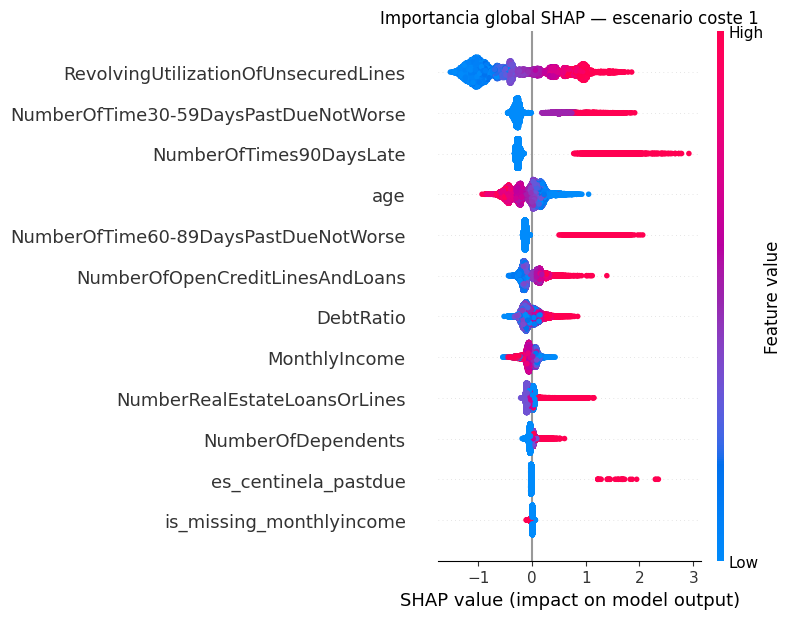

Figura guardada en: results\figures\shap_summary_coste1.png


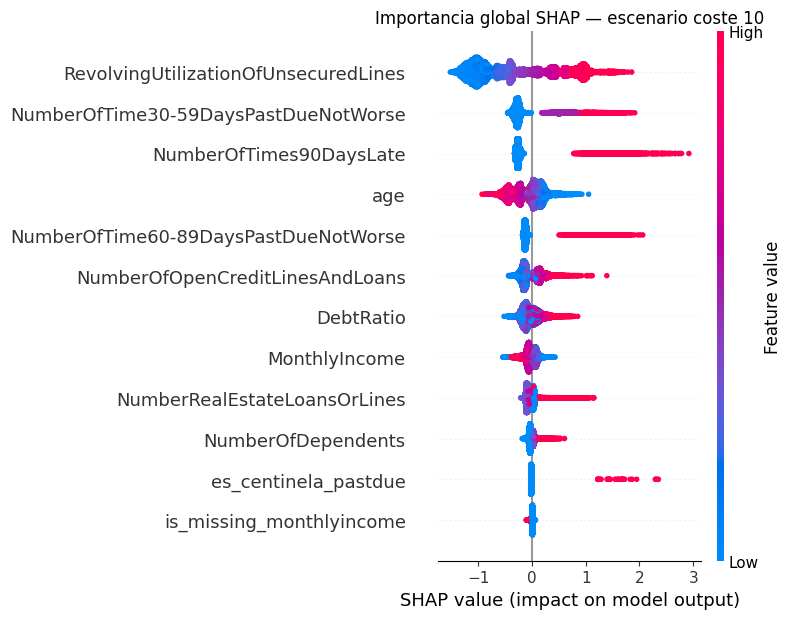

Figura guardada en: results\figures\shap_summary_coste10.png


In [4]:
# 3. Visualizacion de importancia global de variables
import matplotlib.pyplot as plt

ruta_figuras = ROOT / "results" / "figures"
ruta_figuras.mkdir(parents=True, exist_ok=True)


def guardar_summary_plot(valores_shap, nombre_archivo, titulo):
    """Genera y guarda el summary plot de un escenario."""
    plt.figure()

    shap.summary_plot(
        valores_shap,
        show=False,
        max_display=len(valores_shap.feature_names),
    )

    plt.title(titulo)
    plt.tight_layout()

    ruta_salida = ruta_figuras / nombre_archivo

    plt.savefig(
        ruta_salida,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    print(f"Figura guardada en: {ruta_salida.relative_to(ROOT)}")


guardar_summary_plot(
    valores_shap=shap_values_coste1,
    nombre_archivo="shap_summary_coste1.png",
    titulo="Importancia global SHAP — escenario coste 1",
)

guardar_summary_plot(
    valores_shap=shap_values_coste10,
    nombre_archivo="shap_summary_coste10.png",
    titulo="Importancia global SHAP — escenario coste 10",
)

## 4. Calculo de valores SHAP locales para los mismos ejemplos usados en 06_contrafactuals.ipynb

Seleccionar los mismos casos individuales analizados en `06_contrafactuals.ipynb` y calcular
sus valores SHAP locales para ambos modelos, guardando las figuras correspondientes en
`results/figures/shap_local_*.png`.

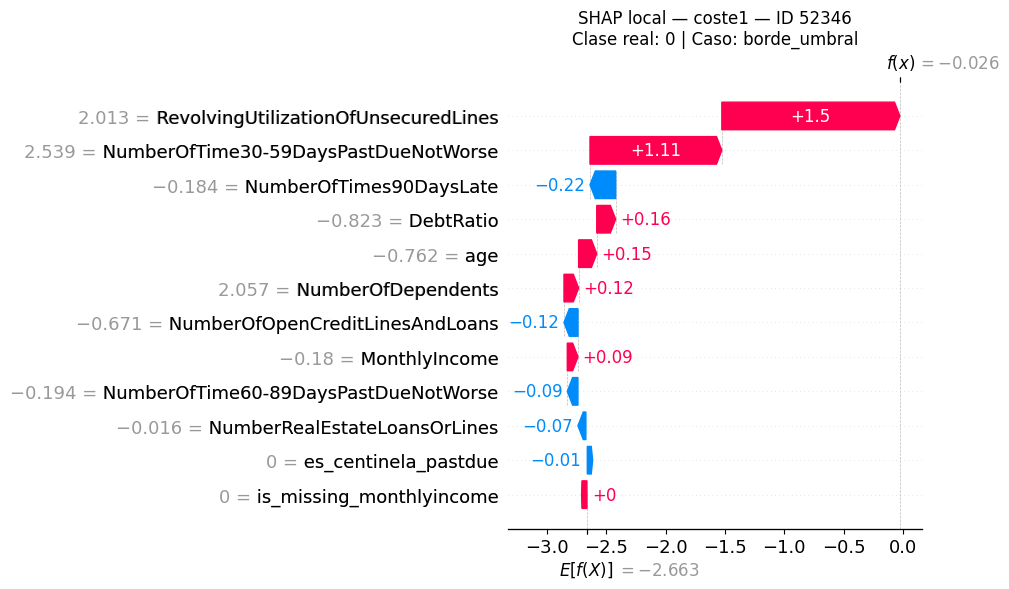

Figura guardada en: results\figures\shap_local_coste1_id_52346.png


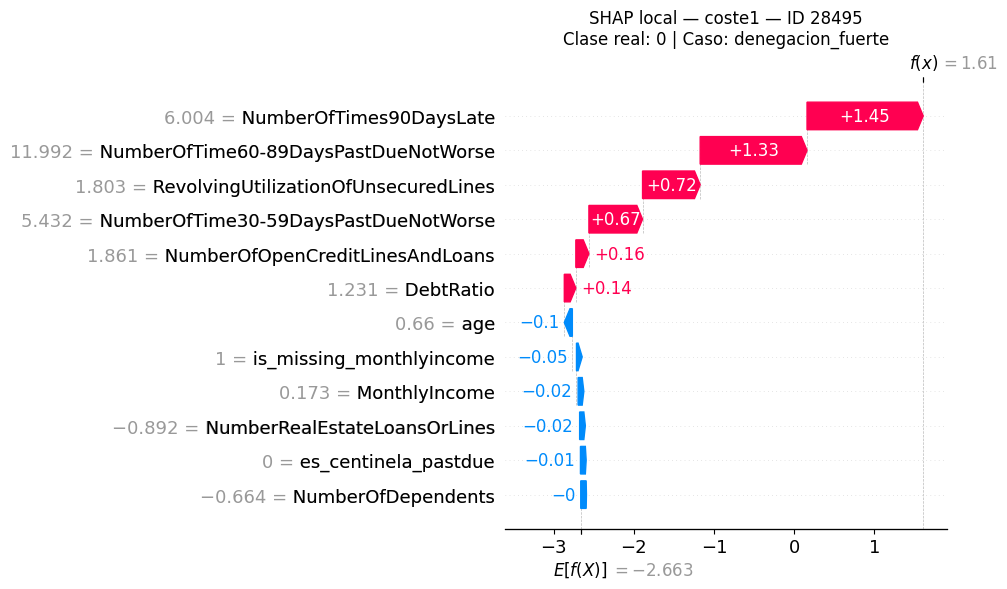

Figura guardada en: results\figures\shap_local_coste1_id_28495.png


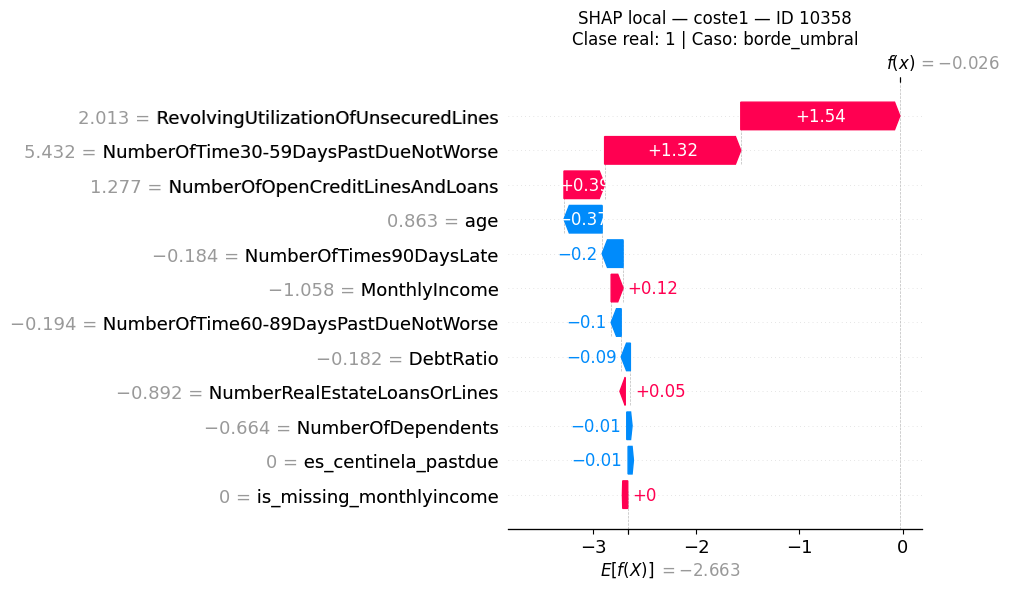

Figura guardada en: results\figures\shap_local_coste1_id_10358.png


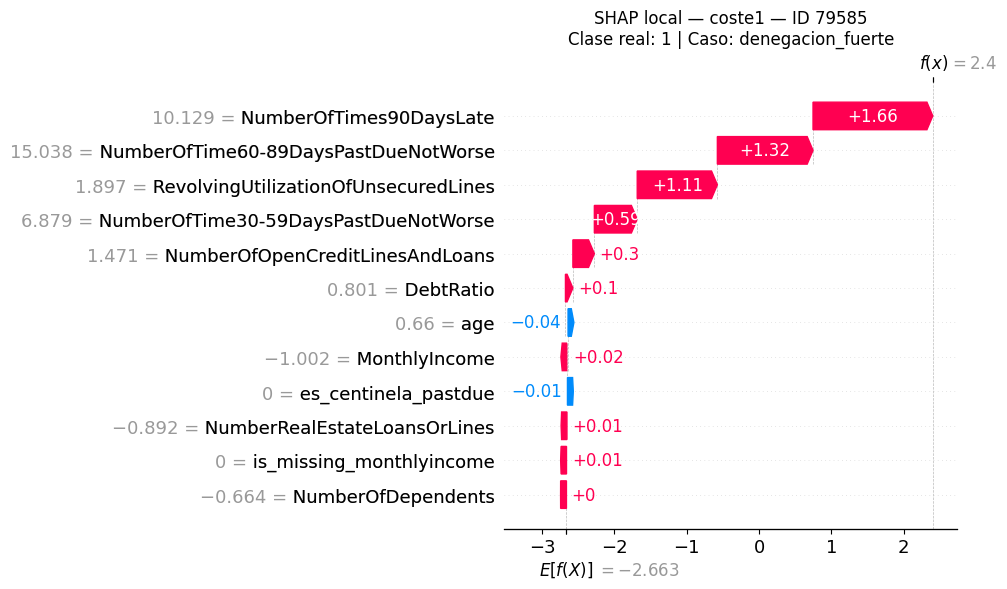

Figura guardada en: results\figures\shap_local_coste1_id_79585.png


In [5]:
# 4. Valores SHAP locales — escenario coste1
import matplotlib.pyplot as plt
import pandas as pd
import shap

ruta_casos = (
    ROOT / "results" / "tables" / "contrafactuals_ejemplos.csv"
)

casos_contrafactuales = pd.read_csv(ruta_casos)

casos_locales_coste1 = (
    casos_contrafactuales[
        casos_contrafactuales["escenario"].eq("coste1")
    ]
    .drop_duplicates(subset="id_test")
    .copy()
)

ruta_figuras = ROOT / "results" / "figures"
ruta_figuras.mkdir(parents=True, exist_ok=True)

for _, caso in casos_locales_coste1.iterrows():
    id_test = int(caso["id_test"])
    clase_real = int(caso["clase_real"])
    tipo_caso = caso["tipo_caso"]

    # Los valores SHAP están ordenados igual que X_test.
    posicion = X_test.index.get_loc(id_test)
    explicacion_local = shap_values_coste1[posicion]

    shap.plots.waterfall(
        explicacion_local,
        max_display=12,
        show=False,
    )

    figura = plt.gcf()
    figura.set_size_inches(10, 6)
    plt.title(
        f"SHAP local — coste1 — ID {id_test}\n"
        f"Clase real: {clase_real} | Caso: {tipo_caso}"
    )
    plt.tight_layout()

    ruta_salida = (
        ruta_figuras / f"shap_local_coste1_id_{id_test}.png"
    )

    figura.savefig(
        ruta_salida,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figura)

    print(f"Figura guardada en: {ruta_salida.relative_to(ROOT)}")

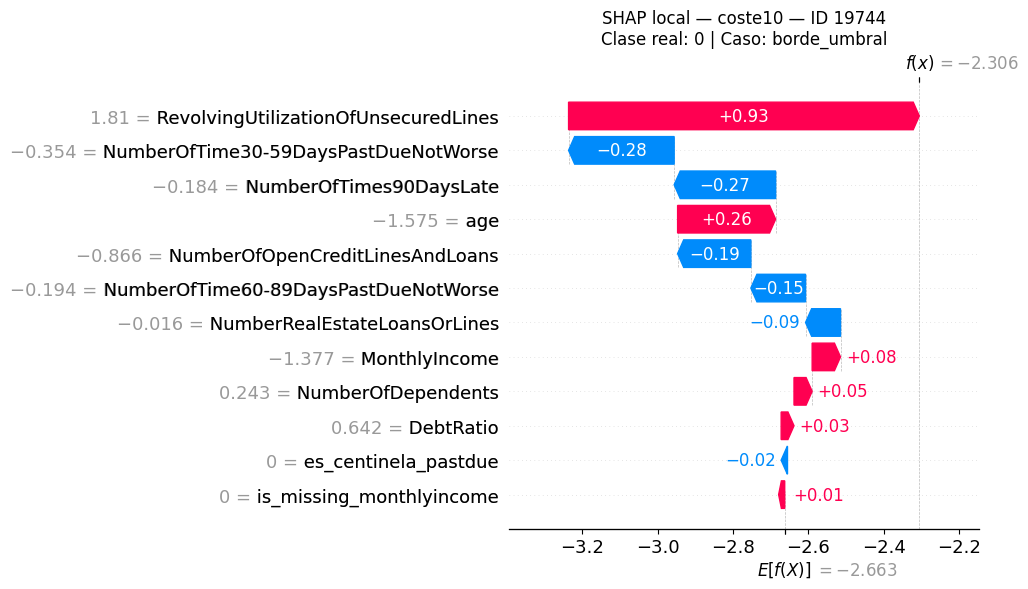

Figura guardada en: results\figures\shap_local_coste10_id_19744.png


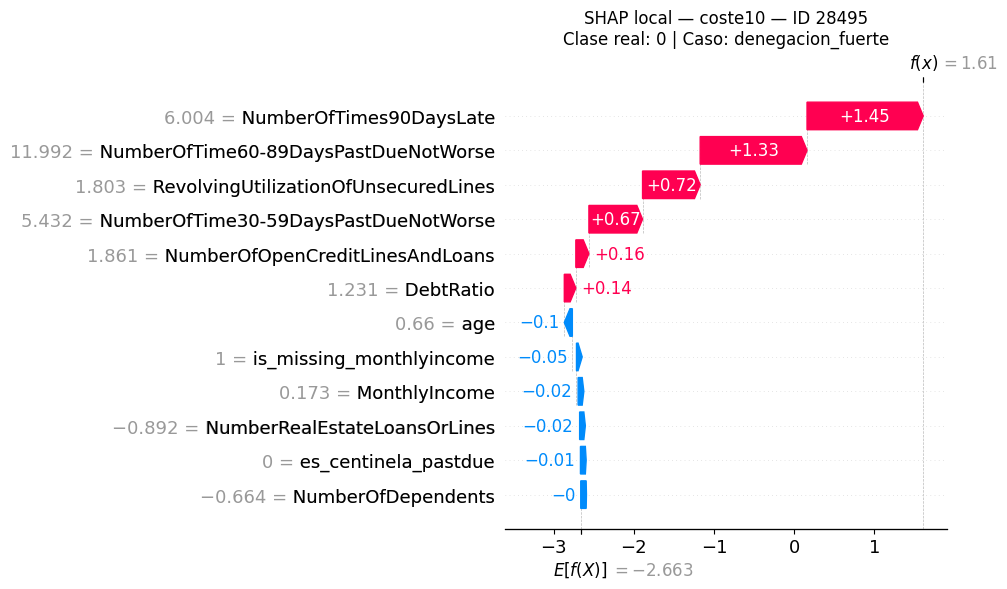

Figura guardada en: results\figures\shap_local_coste10_id_28495.png


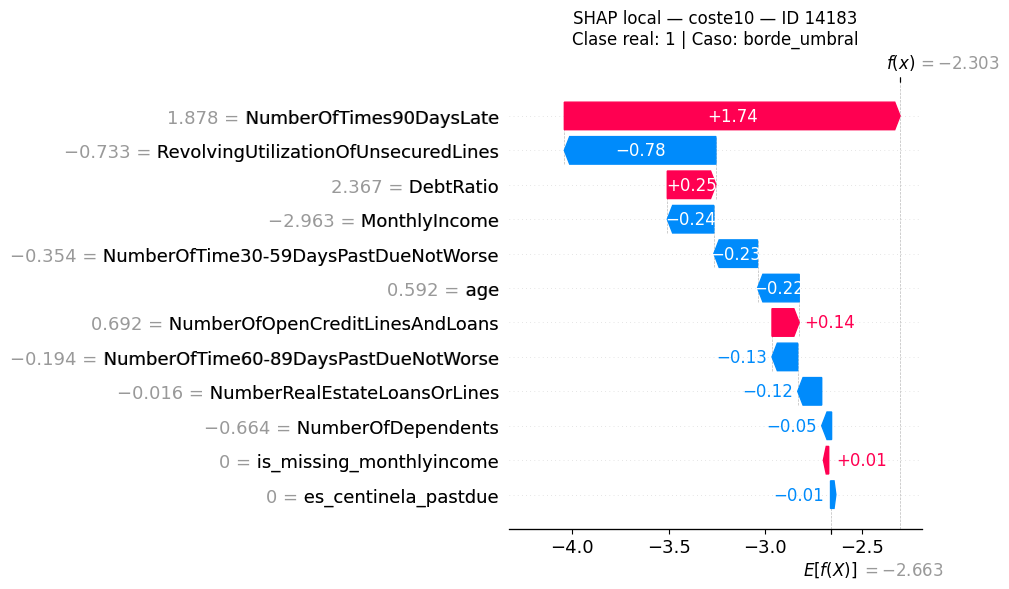

Figura guardada en: results\figures\shap_local_coste10_id_14183.png


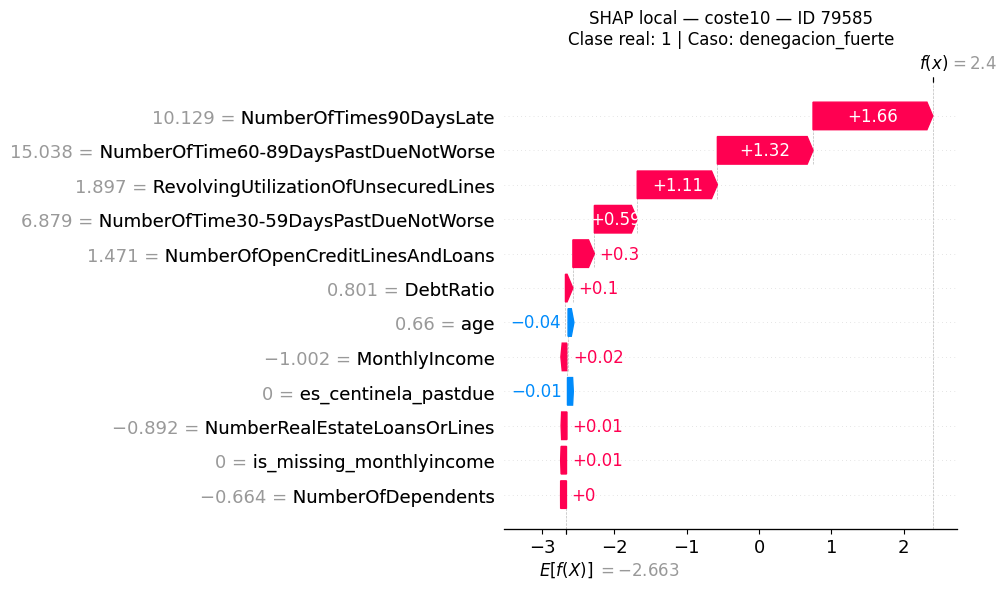

Figura guardada en: results\figures\shap_local_coste10_id_79585.png


In [6]:
# 4. Valores SHAP locales — escenario coste10
import matplotlib.pyplot as plt
import pandas as pd
import shap

ruta_casos = (
    ROOT / "results" / "tables" / "contrafactuals_ejemplos.csv"
)

casos_contrafactuales = pd.read_csv(ruta_casos)

casos_locales_coste10 = (
    casos_contrafactuales[
        casos_contrafactuales["escenario"].eq("coste10")
    ]
    .drop_duplicates(subset="id_test")
    .copy()
)

ruta_figuras = ROOT / "results" / "figures"
ruta_figuras.mkdir(parents=True, exist_ok=True)

for _, caso in casos_locales_coste10.iterrows():
    id_test = int(caso["id_test"])
    clase_real = int(caso["clase_real"])
    tipo_caso = caso["tipo_caso"]

    # Los valores SHAP están ordenados igual que X_test.
    posicion = X_test.index.get_loc(id_test)
    explicacion_local = shap_values_coste10[posicion]

    shap.plots.waterfall(
        explicacion_local,
        max_display=12,
        show=False,
    )

    figura = plt.gcf()
    figura.set_size_inches(10, 6)
    plt.title(
        f"SHAP local — coste10 — ID {id_test}\n"
        f"Clase real: {clase_real} | Caso: {tipo_caso}"
    )
    plt.tight_layout()

    ruta_salida = (
        ruta_figuras / f"shap_local_coste10_id_{id_test}.png"
    )

    figura.savefig(
        ruta_salida,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figura)

    print(f"Figura guardada en: {ruta_salida.relative_to(ROOT)}")

## 5. Comparacion de hallazgos entre el escenario coste1 y coste10

Contrastar las variables mas influyentes (global) y las explicaciones locales obtenidas entre
los dos escenarios de coste, senalando coincidencias y diferencias.

In [9]:
# 5. Comparacion de hallazgos entre el escenario coste1 y coste10
from IPython.display import Markdown, display
import numpy as np
import pandas as pd

# Comparacion global: ranking e importancia media absoluta
comparacion_global = shap_global.pivot(
    index="feature",
    columns="escenario",
    values=["ranking", "mean_abs_shap"],
)

comparacion_global.columns = [
    f"{metrica}_{escenario}"
    for metrica, escenario in comparacion_global.columns
]

comparacion_global = comparacion_global.reset_index()

comparacion_global["diferencia_ranking"] = (
    comparacion_global["ranking_coste10"]
    - comparacion_global["ranking_coste1"]
)

comparacion_global["diferencia_mean_abs_shap"] = (
    comparacion_global["mean_abs_shap_coste10"]
    - comparacion_global["mean_abs_shap_coste1"]
)

comparacion_global = (
    comparacion_global
    .sort_values("ranking_coste1")
    .reset_index(drop=True)
)

display(Markdown("### Comparacion global"))
display(comparacion_global.round(6))


# Comparacion local sobre los individuos presentes en ambos escenarios
ids_coste1 = set(casos_locales_coste1["id_test"].astype(int))
ids_coste10 = set(casos_locales_coste10["id_test"].astype(int))
ids_comunes = sorted(ids_coste1 & ids_coste10)

filas_locales = []

for id_test in ids_comunes:
    posicion = X_test.index.get_loc(id_test)

    valores_1 = np.asarray(
        shap_values_coste1[posicion].values
    )
    valores_10 = np.asarray(
        shap_values_coste10[posicion].values
    )

    filas_locales.append({
        "id_test": id_test,
        "max_diferencia_abs_shap": np.max(
            np.abs(valores_10 - valores_1)
        ),
        "coincide_explicacion_shap": np.allclose(
            valores_1,
            valores_10,
        ),
    })

comparacion_local = pd.DataFrame(filas_locales)

display(Markdown(
    "### Comparacion local en los mismos individuos"
))
display(comparacion_local)


# Los casos de borde cambian porque cada escenario busca
# observaciones proximas a un umbral diferente.
casos_borde = (
    casos_contrafactuales.loc[
        casos_contrafactuales["tipo_caso"].eq("borde_umbral"),
        [
            "escenario",
            "id_test",
            "clase_real",
            "proba_impago",
            "umbral",
        ],
    ]
    .sort_values(["escenario", "clase_real"])
    .reset_index(drop=True)
)

casos_borde["margen_sobre_umbral"] = (
    casos_borde["proba_impago"]
    - casos_borde["umbral"]
)

display(Markdown(
    "### Diferencia clara: cambia el umbral y, con el, "
    "los casos de borde"
))
display(casos_borde.round(6))


# Resumen interpretativo
umbral_1 = float(modelo_coste1["umbral"])
umbral_10 = float(modelo_coste10["umbral"])

max_dif_global = (
    comparacion_global["diferencia_mean_abs_shap"]
    .abs()
    .max()
)

max_dif_local = (
    comparacion_local["max_diferencia_abs_shap"].max()
    if not comparacion_local.empty
    else np.nan
)

display(Markdown(f"""
### Hallazgos comparados

- **Coincidencia global total:** ambos escenarios presentan
  exactamente el mismo ranking y la misma importancia SHAP. La
  diferencia maxima de `mean_abs_shap` es **{max_dif_global:.6g}**.
  En ambos domina `RevolvingUtilizationOfUnsecuredLines`, seguida
  por los indicadores de morosidad de 30-59 y 90 dias, y por `age`.

- **Coincidencia local para una misma persona:** en los IDs comunes
  {ids_comunes}, las atribuciones SHAP tambien coinciden. La diferencia
  maxima es **{max_dif_local:.6g}**. Por tanto, el modelo explica el
  score individual de la misma manera en `coste1` y `coste10`.

- **Diferencia principal:** no cambian las variables influyentes, sino
  la regla de decision. El umbral baja de **{umbral_1:.4f}** en
  `coste1` a **{umbral_10:.4f}** en `coste10`, porque un falso negativo
  cuesta diez veces mas. En consecuencia, `coste10` clasifica como
  riesgo 1 desde probabilidades mucho menores.

- **Diferencia en los casos locales de borde:** `coste1` selecciona
  los IDs {sorted(ids_coste1 - ids_coste10)} alrededor de 0.493,
  mientras que `coste10` selecciona
  {sorted(ids_coste10 - ids_coste1)} alrededor de 0.091. Sus graficos
  SHAP difieren porque son personas distintas, escogidas alrededor de
  umbrales diferentes, no porque el modelo haya aprendido relaciones
  diferentes.

- **Casos fuertes coincidentes:** los IDs {ids_comunes} aparecen en
  ambos escenarios y mantienen su score y su explicacion SHAP. En
  `coste10`, esos scores quedan mucho mas alejados del umbral inferior,
  por lo que la denegacion resulta mas holgada.
"""))

### Comparacion global

,feature,ranking_coste1,ranking_coste10,mean_abs_shap_coste1,mean_abs_shap_coste10,diferencia_ranking,diferencia_mean_abs_shap
0,RevolvingUtilizationOfUnsecuredLines,1.0,1.0,0.787252,0.787252,0.0,0.0
1,NumberOfTime30-59DaysPastDueNotWorse,2.0,2.0,0.348599,0.348599,0.0,0.0
2,NumberOfTimes90DaysLate,3.0,3.0,0.327756,0.327756,0.0,0.0
3,age,4.0,4.0,0.227283,0.227283,0.0,0.0
4,NumberOfTime60-89DaysPastDueNotWorse,5.0,5.0,0.173540,0.173540,0.0,0.0
5,NumberOfOpenCreditLinesAndLoans,6.0,6.0,0.159189,0.159189,0.0,0.0
6,DebtRatio,7.0,7.0,0.129320,0.129320,0.0,0.0
7,MonthlyIncome,8.0,8.0,0.088239,0.088239,0.0,0.0
8,NumberRealEstateLoansOrLines,9.0,9.0,0.068172,0.068172,0.0,0.0
9,NumberOfDependents,10.0,10.0,0.043470,0.043470,0.0,0.0


### Comparacion local en los mismos individuos

,id_test,max_diferencia_abs_shap,coincide_explicacion_shap
0,28495,0.0,True
1,79585,0.0,True


### Diferencia clara: cambia el umbral y, con el, los casos de borde

,escenario,id_test,clase_real,proba_impago,umbral,margen_sobre_umbral
0,coste1,52346,0,0.493506,0.493394,0.000112
1,coste1,10358,1,0.493573,0.493394,0.000179
2,coste10,19744,0,0.090614,0.090609,0.000005
3,coste10,14183,1,0.090845,0.090609,0.000236



### Hallazgos comparados

- **Coincidencia global total:** ambos escenarios presentan
  exactamente el mismo ranking y la misma importancia SHAP. La
  diferencia maxima de `mean_abs_shap` es **0**.
  En ambos domina `RevolvingUtilizationOfUnsecuredLines`, seguida
  por los indicadores de morosidad de 30-59 y 90 dias, y por `age`.

- **Coincidencia local para una misma persona:** en los IDs comunes
  [28495, 79585], las atribuciones SHAP tambien coinciden. La diferencia
  maxima es **0**. Por tanto, el modelo explica el
  score individual de la misma manera en `coste1` y `coste10`.

- **Diferencia principal:** no cambian las variables influyentes, sino
  la regla de decision. El umbral baja de **0.4934** en
  `coste1` a **0.0906** en `coste10`, porque un falso negativo
  cuesta diez veces mas. En consecuencia, `coste10` clasifica como
  riesgo 1 desde probabilidades mucho menores.

- **Diferencia en los casos locales de borde:** `coste1` selecciona
  los IDs [10358, 52346] alrededor de 0.493,
  mientras que `coste10` selecciona
  [14183, 19744] alrededor de 0.091. Sus graficos
  SHAP difieren porque son personas distintas, escogidas alrededor de
  umbrales diferentes, no porque el modelo haya aprendido relaciones
  diferentes.

- **Casos fuertes coincidentes:** los IDs [28495, 79585] aparecen en
  ambos escenarios y mantienen su score y su explicacion SHAP. En
  `coste10`, esos scores quedan mucho mas alejados del umbral inferior,
  por lo que la denegacion resulta mas holgada.


## 6. Conclusiones

El análisis SHAP muestra que la variable con mayor influencia global es `RevolvingUtilizationOfUnsecuredLines`. A continuación aparecen las variables relacionadas con los retrasos en los pagos, especialmente `NumberOfTime30-59DaysPastDueNotWorse` y `NumberOfTimes90DaysLate`. La edad también presenta una influencia relevante, aunque menor que la utilización del crédito y el historial de morosidad.

Los escenarios `coste1` y `coste10` presentan exactamente el mismo ranking de variables y los mismos valores SHAP. Esto se debe a que ambos utilizan el mismo modelo XGBoost para estimar la probabilidad de impago. Por tanto, el aumento del coste de los falsos negativos no modifica las relaciones aprendidas por el modelo ni la explicación del riesgo estimado.

Las explicaciones locales confirman este resultado. Cuando se analiza al mismo individuo en ambos escenarios, sus contribuciones SHAP son idénticas: las mismas variables aumentan o reducen su score en la misma magnitud. Las diferencias observadas entre algunos gráficos locales se deben a que los casos próximos al umbral son personas distintas, no a que el modelo las explique de forma diferente.

La diferencia fundamental entre los escenarios se encuentra en la decisión final. En `coste1`, el umbral es aproximadamente **0.4934**, mientras que en `coste10` disminuye hasta **0.0906**. Como los falsos negativos son diez veces más costosos en el segundo escenario, se deniegan solicitudes desde probabilidades de impago mucho menores. Así, `coste10` aplica una política más conservadora: reduce el riesgo de conceder crédito a personas que podrían incumplir, a cambio de rechazar a más solicitantes que finalmente no presentarían impago.

En conclusión, SHAP permite diferenciar dos elementos que no deben confundirse: el modelo determina qué variables explican el riesgo estimado, mientras que el umbral dependiente de los costes determina cómo se transforma ese riesgo en una decisión. En este trabajo, las explicaciones del riesgo permanecen estables entre escenarios; lo que cambia de forma sustancial es la política de decisión.